In [10]:
#Import packages
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Settings
requested_n_pcs = 50
random_state = 42
maximum_k = 10

In [11]:
# Load the data 
adata = sc.read_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [12]:
# Separate the data into three datasets regarding each condition
adata_control = adata[adata.obs["condition"] == "Control"].copy()
adata_ifng = adata[adata.obs["condition"] == "IFNγ"].copy()
adata_coculture = adata[adata.obs["condition"] == "Co-culture"].copy()

In [13]:
# Normalize the dataset adata_control 
sc.pp.normalize_total(adata_control, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_control)

In [14]:
# Normalize the dataset adata_ifng 
sc.pp.normalize_total(adata_ifng, target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata_ifng)

In [15]:
# Normalize the dataset adata_coculture
sc.pp.normalize_total(adata_coculture, target_sum = 1e4)
sc.pp.log1p(adata_coculture)

In [16]:
# Compute HVG
sc.pp.highly_variable_genes(adata_control, n_top_genes=2000)
sc.pp.highly_variable_genes(adata_ifng, n_top_genes=2000)
sc.pp.highly_variable_genes(adata_coculture, n_top_genes=2000)

In [17]:
# Save HVG-filtered datasets
adata_control_hvg = adata_control[:, adata_control.var["highly_variable"]].copy()
adata_ifng_hvg = adata_ifng[:, adata_ifng.var["highly_variable"]].copy()
adata_coculture_hvg = adata_coculture[:, adata_coculture.var["highly_variable"]].copy()
#Print the shape of the data
print(adata_control_hvg.shape)
print(adata_ifng_hvg.shape)
print(adata_coculture_hvg.shape)

(49781, 2000)
(74879, 2000)
(68821, 2000)


In [18]:
# Define a function to calculate a control-relative expression profile for each genetic perturbation
# import packages
import numpy as np
import pandas as pd
from scipy.sparse import issparse
def calculate_control_relative_profiles(
    adata,
    pert_col="perturbation",
    control_name="control",
    remove_control_profile=True
):
    # Check that the perturbation column exists
    # in the AnnData metadata
    if pert_col not in adata.obs.columns:
        raise KeyError(
            f"Column '{pert_col}' was not found in adata.obs."
        )

    # Extract the perturbation label corresponding to each cell
    labels = adata.obs[pert_col].astype(str).to_numpy()

    # Extract the gene-expression matrix
    X = adata.X

    # Convert the expression matrix to a dense representation
    # if it is stored as a sparse matrix
    if issparse(X):
        X = X.toarray()

    # Convert expression values to a NumPy array
    X = np.asarray(X, dtype=np.float32)

    # Create a DataFrame in which rows represent cells,
    # row labels represent their perturbation targets,
    # and columns represent genes
    expression_df = pd.DataFrame(
        X,
        index=labels,
        columns=adata.var_names.astype(str)
    )

    # Calculate the mean expression of every gene
    # separately for each perturbation
    mean_profiles = expression_df.groupby(
        level=0
    ).mean()

    # Check that the unperturbed control profile is available
    if control_name not in mean_profiles.index:
        raise ValueError(
            f"Control label '{control_name}' was not found."
        )

    # Extract the mean gene-expression profile
    # of the unperturbed control cells
    control_profile = mean_profiles.loc[
        control_name
    ]

    # Calculate the control-relative response of each perturbation
    # by subtracting the mean control expression profile
    # from the mean expression profile of each perturbation
    perturbation_profiles = mean_profiles.subtract(
        control_profile,
        axis="columns"
    )

    # The control profile becomes an all-zero vector after
    # subtraction and therefore provides no information for clustering.
    # Remove it before scaling, PCA, and KMeans clustering.
    if remove_control_profile:
        perturbation_profiles = perturbation_profiles.drop(
            index=control_name
        )

    # Return both the control-relative perturbation profiles
    # and the original mean expression profiles
    return perturbation_profiles, mean_profiles

In [19]:
# Calculate control-relative perturbation profiles separately
# for the Control, IFNγ, and Co-culture conditions
# Control condition
profiles_control, mean_profiles_control = (
    calculate_control_relative_profiles(
        adata_control_hvg,
        remove_control_profile=True
    )
)

# IFNγ condition
profiles_ifng, mean_profiles_ifng = (
    calculate_control_relative_profiles(
        adata_ifng_hvg,
        remove_control_profile=True
    )
)

# Co-culture condition
profiles_coculture, mean_profiles_coculture = (
    calculate_control_relative_profiles(
        adata_coculture_hvg,
        remove_control_profile=True
    )
)

In [20]:
#Display the perturbation and gene dimensions for each condition
print("Control perturbation profiles:", profiles_control.shape)
print("IFNγ perturbation profiles:", profiles_ifng.shape)
print("Co-culture perturbation profiles:", profiles_coculture.shape)
print("\nFirst control-condition profiles:")
print(profiles_control.iloc[:5, :5])

Control perturbation profiles: (237, 2000)
IFNγ perturbation profiles: (237, 2000)
Co-culture perturbation profiles: (237, 2000)

First control-condition profiles:
gene_symbol     AADAC     AATBC     ABCB6      ABL2  AC002070.1
A2M         -0.002194 -0.000236  0.006008 -0.019238   -0.000357
ACSL3        0.001662 -0.000236  0.002335 -0.046018   -0.000357
ACTA2       -0.002194 -0.000236  0.002803  0.004826   -0.000357
AEBP1        0.000954  0.001152 -0.003535 -0.011824   -0.000357
AGA          0.000967 -0.000236  0.001519 -0.016586   -0.000357


In [21]:
# Define a function to standardize the perturbation profiles
# and reduce their dimensionality using PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
def scale_and_compute_pca(
    profiles,
    requested_n_pcs=50,
    random_state=42
):
    
    # Check that enough perturbation profiles are available
    # to perform meaningful dimensionality reduction
    if profiles.shape[0] < 3:
        raise ValueError(
            "At least three perturbation profiles are required."
        )

    # Initialize the scaler
    scaler = StandardScaler()

    # Standardize each gene across perturbation profiles
    # so that each gene has approximately mean 0 and standard deviation 1
    scaled_profiles = scaler.fit_transform(
        profiles.to_numpy()
    )

    # Determine the number of PCs that can actually be calculated.
    # PCA cannot use more components than the number of
    # perturbation profiles or the number of genes.
    actual_n_pcs = min(
        requested_n_pcs,
        scaled_profiles.shape[0],
        scaled_profiles.shape[1]
    )

    # Initialize PCA using the selected number of components
    pca_model = PCA(
        n_components=actual_n_pcs,
        random_state=random_state
    )

    # Project the standardized perturbation profiles
    # into the lower-dimensional PCA space
    pca_coordinates = pca_model.fit_transform(
        scaled_profiles
    )

    # Return the transformed data and fitted preprocessing models
    # for subsequent clustering and interpretation
    return {
        "scaled": scaled_profiles,
        "pca": pca_coordinates,
        "scaler": scaler,
        "pca_model": pca_model,
        "n_pcs": actual_n_pcs
    }

In [22]:
# Use this function for the control condition 
control_results = scale_and_compute_pca(
    profiles_control,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)
# Use this function for the IFNG condition 
ifng_results = scale_and_compute_pca(
    profiles_ifng,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)
# Use this function for the coculture condition 
coculture_results = scale_and_compute_pca(
    profiles_coculture,
    requested_n_pcs=requested_n_pcs,
    random_state=random_state
)

In [23]:
# Get the scaled perturbation profiles for each condition
control_scaled = control_results["scaled"]
ifng_scaled = ifng_results["scaled"]
coculture_scaled = coculture_results["scaled"]

# Get the PCA-transformed perturbation profiles for each condition
# These PCA coordinates will be used for the clustering analysis
control_pca = control_results["pca"]
ifng_pca = ifng_results["pca"]
coculture_pca = coculture_results["pca"]

In [24]:
# Check the dimensions of the scaled data and PCA results for each condition
print("Control scaled:", control_scaled.shape)
print("Control PCA:", control_pca.shape)

print("IFNγ scaled:", ifng_scaled.shape)
print("IFNγ PCA:", ifng_pca.shape)

print("Co-culture scaled:", coculture_scaled.shape)
print("Co-culture PCA:", coculture_pca.shape)

Control scaled: (237, 2000)
Control PCA: (237, 50)
IFNγ scaled: (237, 2000)
IFNγ PCA: (237, 50)
Co-culture scaled: (237, 2000)
Co-culture PCA: (237, 50)


In [25]:
# Check how much of the total variation in the perturbation profiles
# is explained by the PCA components for each condition
print(
    "Control variance explained by PCA:",
    control_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

print(
    "IFNγ variance explained by PCA:",
    ifng_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

print(
    "Co-culture variance explained by PCA:",
    coculture_results["pca_model"]
    .explained_variance_ratio_
    .sum()
)

Control variance explained by PCA: 0.46204522
IFNγ variance explained by PCA: 0.45798337
Co-culture variance explained by PCA: 0.5003339


In [26]:
import numpy as np
import matplotlib.pyplot as plt
# Define a function to visualize how much variance
# is explained by the PCA components
def plot_pca_variance(pca_results, condition_name):
    
    # Get the proportion of variance explained by each principal component
    explained_variance = (
        pca_results["pca_model"].explained_variance_ratio_
    )

    # Calculate the cumulative variance explained
    # as more principal components are included
    cumulative_variance = np.cumsum(explained_variance)

    # Create PC numbers starting from 1
    pc_numbers = np.arange(
        1,
        len(explained_variance) + 1
    )

    # Plot the variance explained by each individual PC
    plt.figure(figsize=(8, 5))

    plt.plot(
        pc_numbers,
        explained_variance,
        marker="o"
    )

    # Add labels and title
    plt.xlabel("Principal component")
    plt.ylabel("Explained variance ratio")
    plt.title(
        f"{condition_name}: variance explained by each PC"
    )

    plt.xticks(pc_numbers)
    plt.tight_layout()
    plt.show()

    # Plot the cumulative variance explained
    # by increasing numbers of PCs
    plt.figure(figsize=(8, 5))

    plt.plot(
        pc_numbers,
        cumulative_variance,
        marker="o"
    )
    # Add labels and title
    plt.xlabel("Number of principal components")
    plt.ylabel("Cumulative explained variance")
    plt.title(
        f"{condition_name}: cumulative PCA variance"
    )

    # Set the axis limits and display the variance thresholds
    plt.xticks(pc_numbers)
    plt.ylim(0, 1.02)
    plt.legend()

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

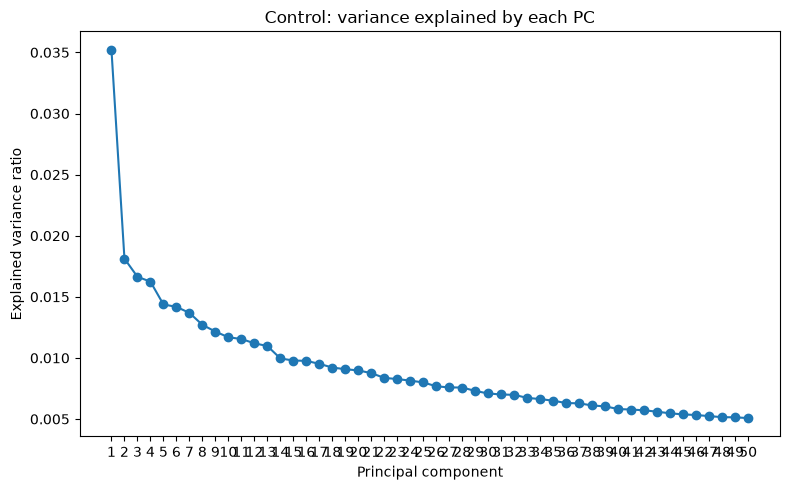

/tmp/ipykernel_656490/88632736.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


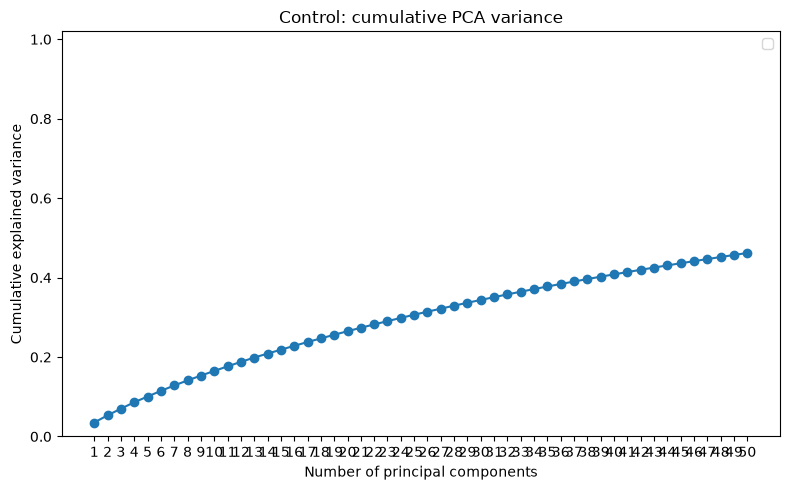

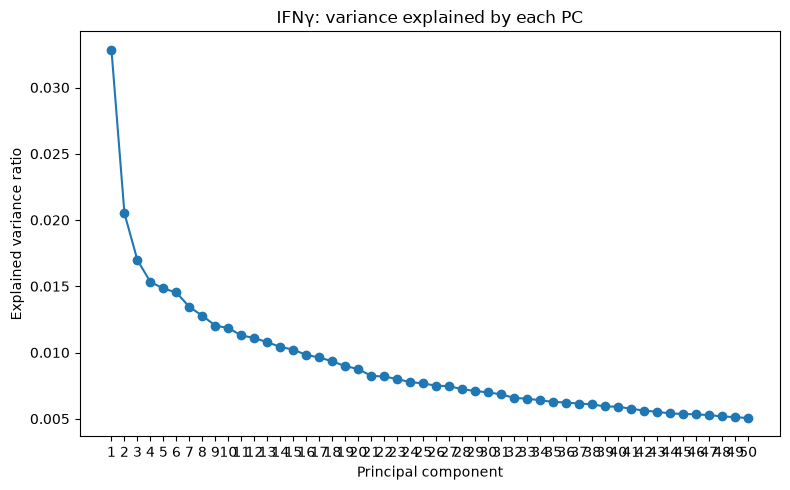

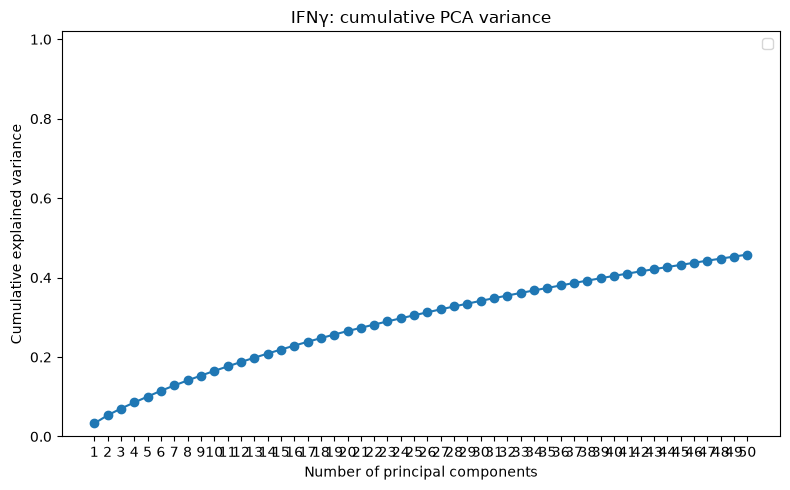

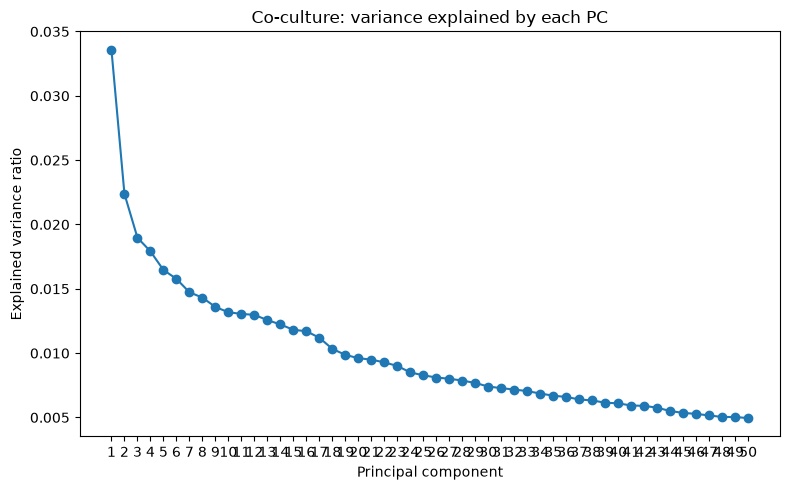

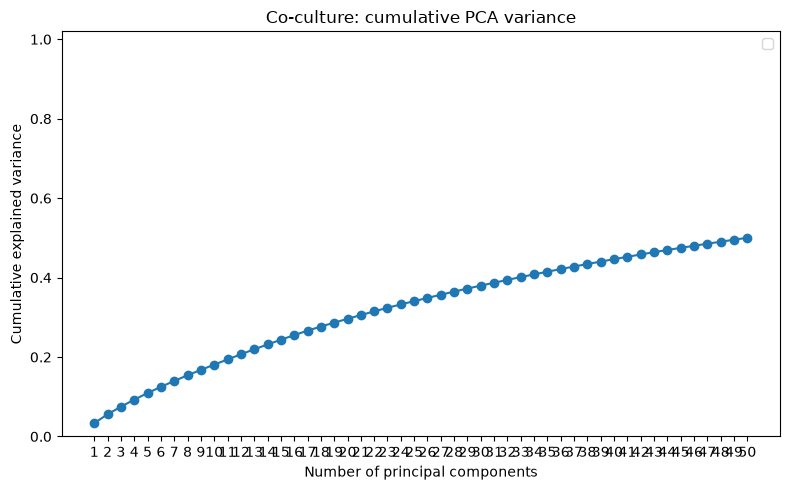

In [27]:
# Plot the variance for each condition
plot_pca_variance(
    control_results,
    "Control"
)

plot_pca_variance(
    ifng_results,
    "IFNγ"
)

plot_pca_variance(
    coculture_results,
    "Co-culture"
)

In [28]:

# import packages
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Define a function to evaluate different numbers of K-means clusters
# using the elbow method and silhouette score
def evaluate_kmeans_clusters(
    pca_coordinates,
    condition_name,
    maximum_k=10,
    n_pcs_for_clustering=50,
    random_state=42,
    n_init=20
):
    
    # Use up to the first 50 principal components for clustering
    actual_pcs_for_clustering = min(
        n_pcs_for_clustering,
        pca_coordinates.shape[1]
    )

    # Select the PCA coordinates that will be used for K-means
    X = pca_coordinates[
        :,
        :actual_pcs_for_clustering
    ]

    # Determine the largest possible number of clusters.
    # Silhouette score requires k to be smaller than
    # the total number of perturbation profiles.
    largest_valid_k = min(
        maximum_k,
        X.shape[0] - 1
    )

    # Check that there are enough perturbations
    # to evaluate at least two clusters
    if largest_valid_k < 2:
        raise ValueError(
            f"Not enough perturbations in {condition_name} "
            f"to evaluate K-means."
        )

    # Create the range of cluster numbers to test
    k_values = list(
        range(2, largest_valid_k + 1)
    )

    # Create empty lists to store the evaluation results
    inertia_values = []
    silhouette_values = []

    # Test K-means for each possible number of clusters
    for k in k_values:

        # Create the K-means model
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init
        )

        # Fit K-means and assign each perturbation to a cluster
        cluster_labels = kmeans.fit_predict(X)

        # Store the inertia for the elbow method
        inertia_values.append(
            kmeans.inertia_
        )

        # Calculate and store the silhouette score
        # to measure how well separated the clusters are
        silhouette_values.append(
            silhouette_score(
                X,
                cluster_labels
            )
        )

    # Store the results for all tested k values in a table
    results_table = pd.DataFrame({
        "k": k_values,
        "inertia": inertia_values,
        "silhouette_score": silhouette_values
    })

    # Find the number of clusters with the
    # highest silhouette score
    best_k_silhouette = int(
        results_table.loc[
            results_table["silhouette_score"].idxmax(),
            "k"
        ]
    )

    # Display the clustering results for the current condition
    print(f"\n{condition_name}")

    print(
        f"PCs used for clustering: "
        f"{actual_pcs_for_clustering}"
    )

    print(results_table)

    print(
        f"Highest silhouette score: k = "
        f"{best_k_silhouette}"
    )

    # Return the evaluation table and the best k
    # according to the silhouette score
    return results_table, best_k_silhouette

In [29]:
# Evaluate different numbers of K-means clusters for the conditions
# using the first 50 PCs, elbow inertia, and silhouette scores
control_k_results, control_best_k = evaluate_kmeans_clusters(
    control_pca,
    condition_name="Control",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)

ifng_k_results, ifng_best_k = evaluate_kmeans_clusters(
    ifng_pca,
    condition_name="IFNγ",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)

coculture_k_results, coculture_best_k = evaluate_kmeans_clusters(
    coculture_pca,
    condition_name="Co-culture",
    maximum_k=maximum_k,
    n_pcs_for_clustering=50,
    random_state=random_state,
    n_init=20
)


Control
PCs used for clustering: 50
    k        inertia  silhouette_score
0   2  207745.046875          0.468479
1   3  200132.500000          0.459730
2   4  195045.000000          0.438857
3   5  187507.796875          0.386977
4   6  182725.000000          0.470473
5   7  176686.093750          0.439075
6   8  170605.875000          0.412881
7   9  165358.218750          0.418381
8  10  161599.937500          0.404038
Highest silhouette score: k = 6

IFNγ
PCs used for clustering: 50
    k        inertia  silhouette_score
0   2  205909.437500          0.501732
1   3  198214.500000          0.491041
2   4  191322.640625          0.392220
3   5  186465.500000          0.387445
4   6  179195.640625          0.387968
5   7  173844.812500          0.395495
6   8  166499.921875          0.389165
7   9  162372.171875          0.394118
8  10  156402.671875          0.392362
Highest silhouette score: k = 2

Co-culture
PCs used for clustering: 50
    k        inertia  silhouette_score
0   2 

In [30]:
# Define a function to plot the K-means evaluation results
# using the elbow method and silhouette score
def plot_kmeans_evaluation(
    results_table,
    condition_name
):
    
    # Plot inertia for each tested number of clusters
    # to visually identify a possible elbow
    plt.figure(figsize=(7, 5))

    plt.plot(
        results_table["k"],
        results_table["inertia"],
        marker="o"
    )

    # Add axis labels and title
    plt.xticks(results_table["k"])
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title(
        f"Elbow method – {condition_name}"
    )

    plt.tight_layout()
    plt.show()

    # Plot the silhouette score for each tested
    # number of clusters
    plt.figure(figsize=(7, 5))

    plt.plot(
        results_table["k"],
        results_table["silhouette_score"],
        marker="o"
    )

    # Find the k value with the highest silhouette score
    best_row = results_table.loc[
        results_table["silhouette_score"].idxmax()
    ]

    # Mark the number of clusters with the
    # highest silhouette score
    plt.axvline(
        best_row["k"],
        linestyle="--",
        label=(
            f"Highest silhouette: "
            f"k = {int(best_row['k'])}"
        )
    )

    # Add axis labels and title
    plt.xticks(results_table["k"])
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.title(
        f"Silhouette analysis – {condition_name}"
    )

    # Display the best k label and the final plot
    plt.legend()
    plt.tight_layout()
    plt.show()

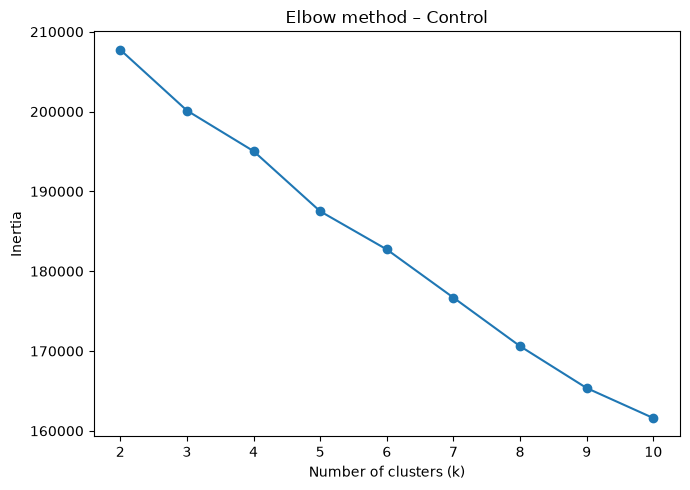

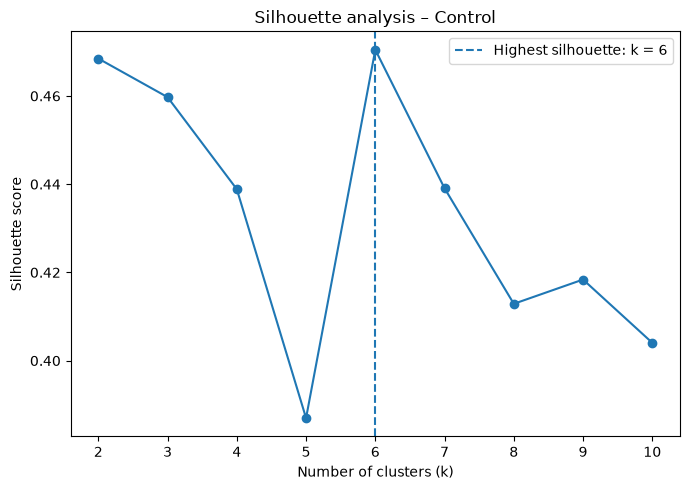

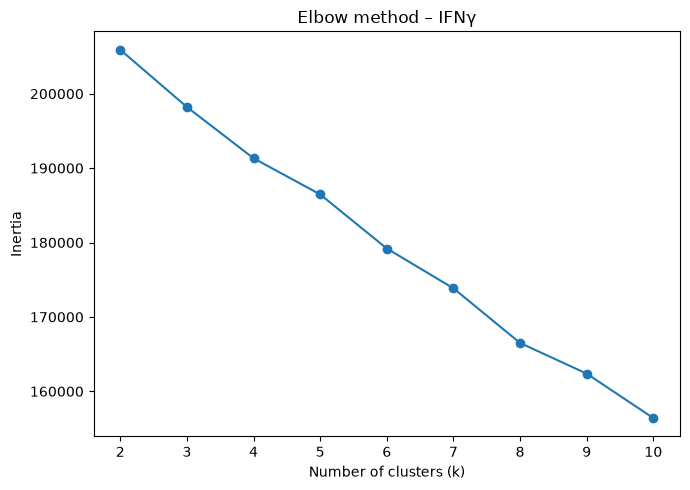

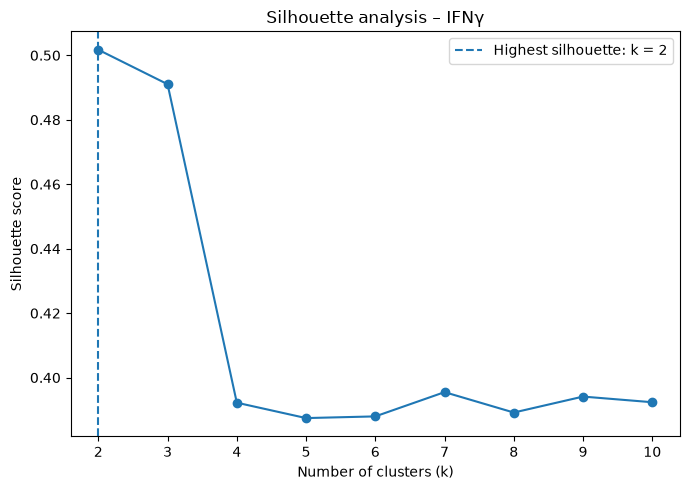

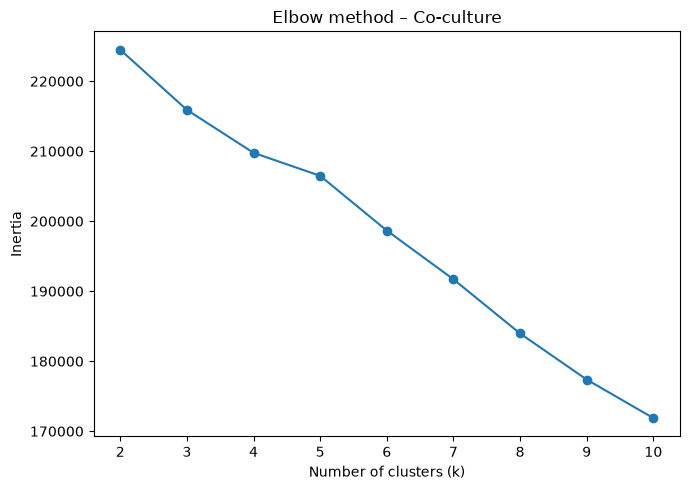

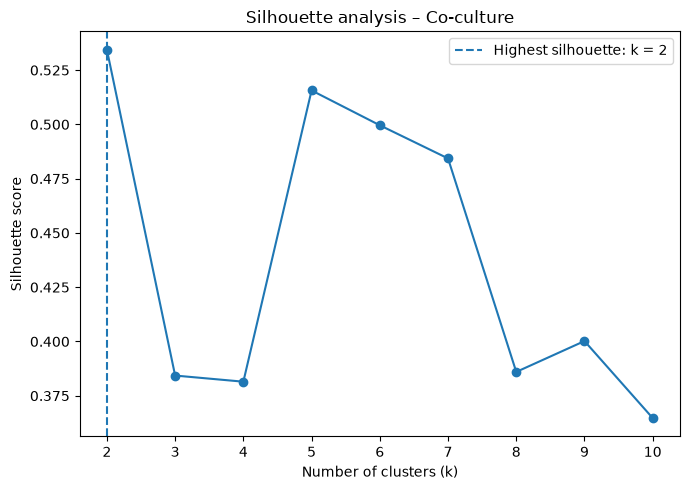

In [31]:
#Plot it for the conditions
plot_kmeans_evaluation(
    control_k_results,
    "Control"
)

plot_kmeans_evaluation(
    ifng_k_results,
    "IFNγ"
)

plot_kmeans_evaluation(
    coculture_k_results,
    "Co-culture"
)

In [32]:
from sklearn.cluster import KMeans

# Define the final number of clusters for each condition
# based on the elbow and silhouette analyses
# k = Control, g = IFNγ, c = Co-culture
k = 6
g = 2
c = 2

# Use the first 50 principal components for clustering
n_pcs = 50

# Create the K-means model for the Control condition
# using four clusters
kmeans_control = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

# Fit K-means to the Control PCA coordinates
# and assign each perturbation to a cluster
control_clusters = kmeans_control.fit_predict(
    control_pca[:, :n_pcs]
)

# Create the K-means model for the IFNG condition
# using two clusters
kmeans_ifng = KMeans(
    n_clusters=g,
    random_state=42,
    n_init=20
)

# Fit K-means to the IFNG PCA coordinates
# and assign each perturbation to a cluster
ifng_clusters = kmeans_ifng.fit_predict(
    ifng_pca[:, :n_pcs]
)

# Create the K-means model for the Co-culture condition
# using two clusters
kmeans_coculture = KMeans(
    n_clusters=c,
    random_state=42,
    n_init=20
)

# Fit K-means to the Co-culture PCA coordinates
# and assign each perturbation to a cluster
coculture_clusters = kmeans_coculture.fit_predict(
    coculture_pca[:, :n_pcs]
)

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Define a function to visualize the K-means clusters
# using the first two principal components
def plot_kmeans_pca(
    pca,
    clusters,
    perturbation_names,
    title
):
    # Create the figure
    plt.figure(figsize=(8, 6))

    # Identify the different K-means clusters
    unique_clusters = np.sort(
        np.unique(clusters)
    )

    # Generate one color for each cluster
    cmap = plt.get_cmap("tab10")

    # Plot the perturbations belonging to each cluster
    for i, cluster in enumerate(unique_clusters):

        # Select perturbations assigned to the current cluster
        idx = clusters == cluster

        # Plot their positions using PC1 and PC2
        plt.scatter(
            pca[idx, 0],
            pca[idx, 1],
            s=80,
            color=cmap(i),
            edgecolor="black",
            label=f"Cluster {cluster}"
        )

    # Add the perturbation name next to each point
    for i, pert in enumerate(perturbation_names):
        plt.text(
            pca[i, 0] + 0.05,
            pca[i, 1] + 0.05,
            str(pert),
            fontsize=8
        )

    # Label the two PCA axes
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)

    # Place the cluster legend outside the main plot
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()

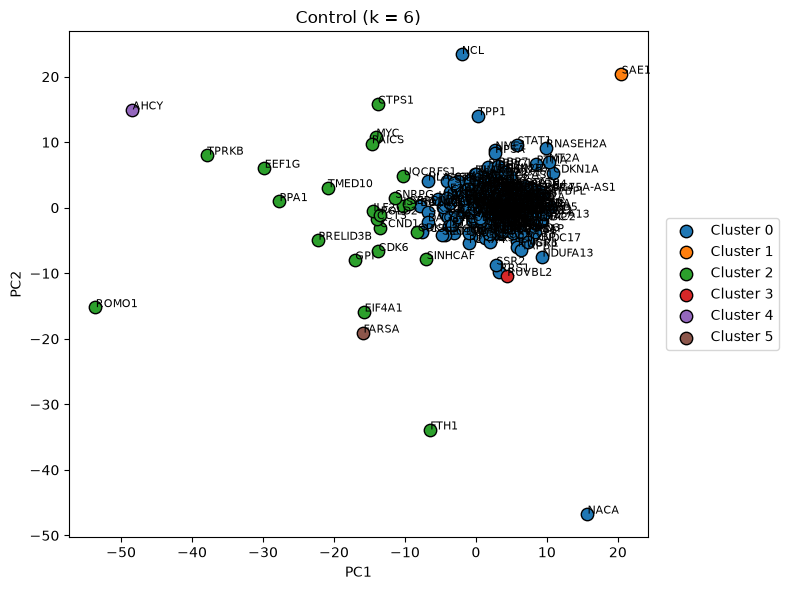

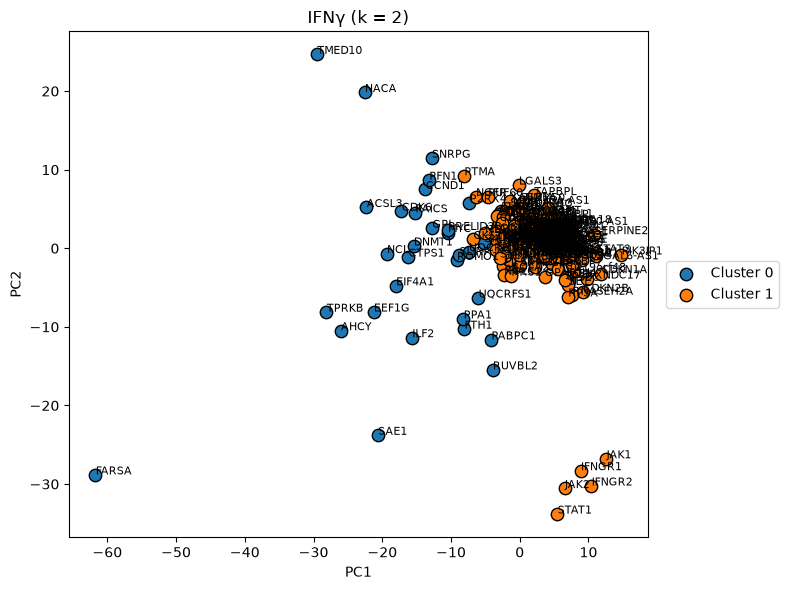

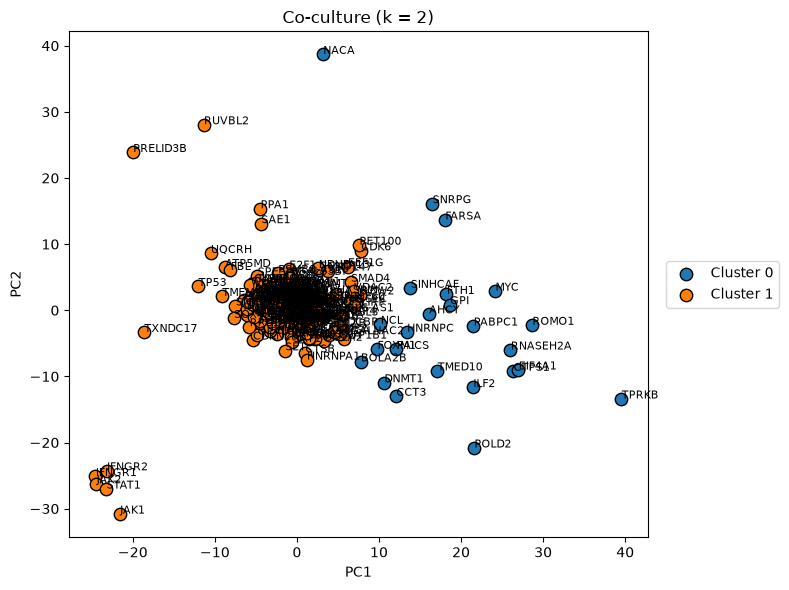

In [35]:
# Plot the K-means clusters for the conditions
# using PC1 and PC2 for visualization
plot_kmeans_pca(
    control_pca,
    control_clusters,
    profiles_control.index,
    "Control (k = 6)"
)

plot_kmeans_pca(
    ifng_pca,
    ifng_clusters,
    profiles_ifng.index,
    "IFNγ (k = 2)"
)

plot_kmeans_pca(
    coculture_pca,
    coculture_clusters,
    profiles_coculture.index,
    "Co-culture (k = 2)"
)

In [45]:
# Import packages
import os
import matplotlib.pyplot as plt
import numpy as np

# Create a folder called results
os.makedirs("results", exist_ok=True)

# Define a function to plot K-means clusters on the first two PCs
# and save the resulting figure
def plot_kmeans_pca(pca, clusters, perturbation_names, title, filename):

    # Create the figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Get the unique cluster numbers and assign a color to each cluster
    unique_clusters = np.sort(np.unique(clusters))
    cmap = plt.get_cmap("tab10")

    # Plot the perturbations separately for each cluster
    for i, cluster in enumerate(unique_clusters):

        # Select perturbations belonging to the current cluster
        idx = clusters == cluster

        # Plot their positions using PC1 and PC2
        ax.scatter(
            pca[idx, 0],
            pca[idx, 1],
            s=80,
            color=cmap(i),
            edgecolor="black",
            label=f"Cluster {cluster}"
        )

    # Add the perturbation name next to each point
    for i, pert in enumerate(perturbation_names):
        ax.text(
            pca[i, 0] + 0.05,
            pca[i, 1] + 0.05,
            pert,
            fontsize=8
        )

    # Add axis labels and plot title
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)

    # Place the cluster legend outside the plot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    # Adjust the layout
    plt.tight_layout()

    # Save the figure in the results folder
    output_path = os.path.join("results", filename)

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    # Display the plot
    plt.show()

    print(f"Plot saved to: {output_path}")

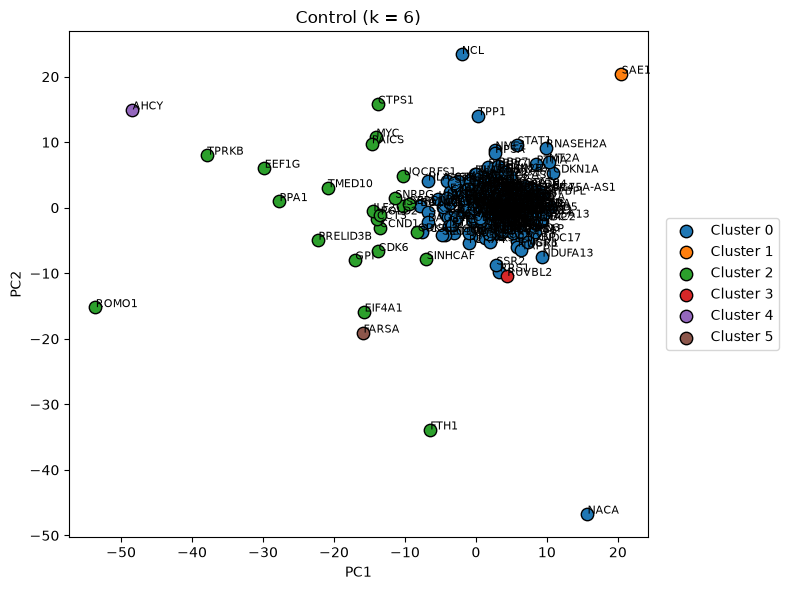

Plot saved to: results/control_kmeans_k6.png


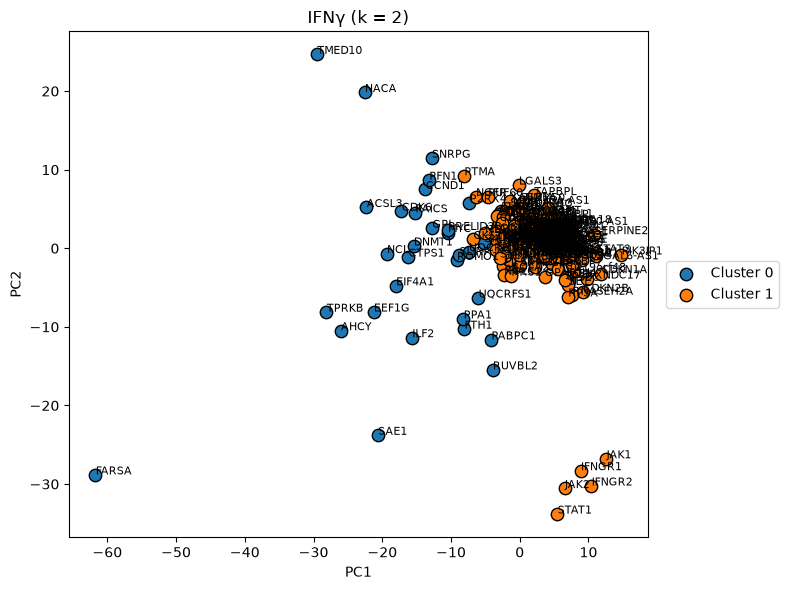

Plot saved to: results/ifng_kmeans_k2.png


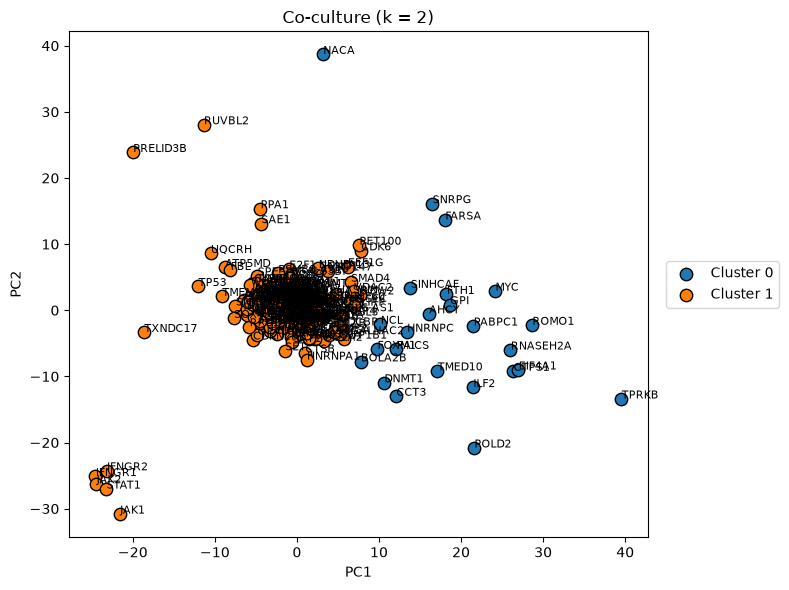

Plot saved to: results/coculture_kmeans_k2.png


In [46]:
#Save the plots from three conditions
plot_kmeans_pca(
    control_pca,
    control_clusters,
    profiles_control.index,
    "Control (k = 6)",
    "control_kmeans_k6.png"
)

plot_kmeans_pca(
    ifng_pca,
    ifng_clusters,
    profiles_ifng.index,
    "IFNγ (k = 2)",
    "ifng_kmeans_k2.png"
)

plot_kmeans_pca(
    coculture_pca,
    coculture_clusters,
    profiles_coculture.index,
    "Co-culture (k = 2)",
    "coculture_kmeans_k2.png"
)

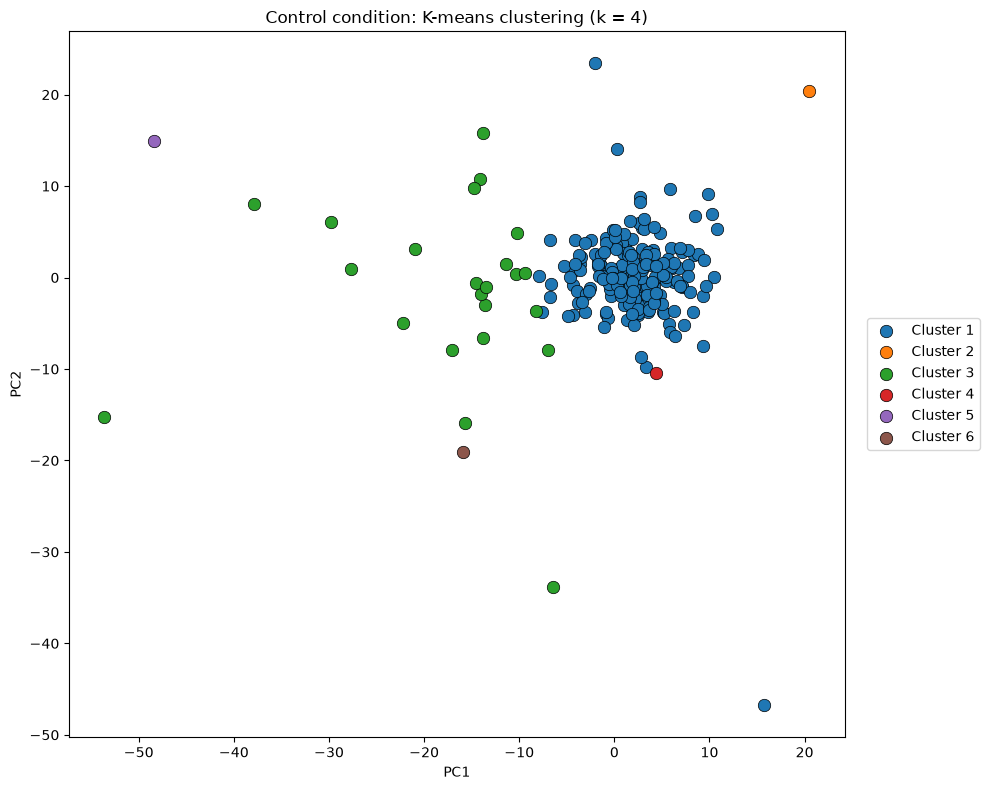

Saved to: results/control_kmeans_k4.png


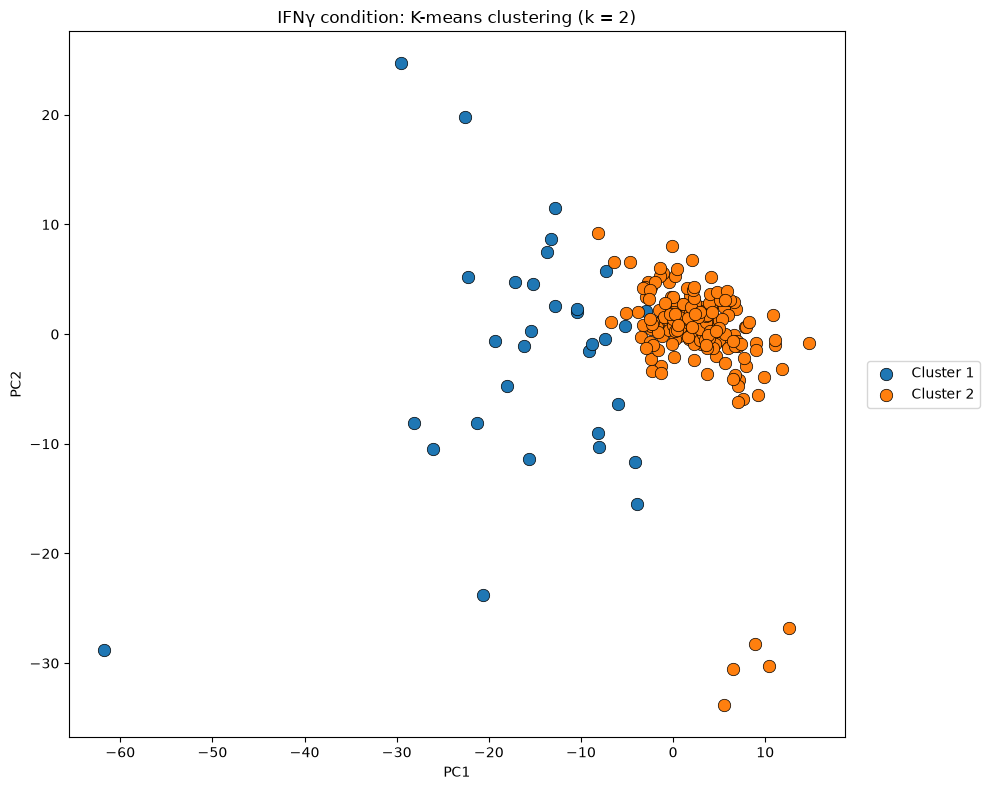

Saved to: results/ifng_kmeans_k2.png


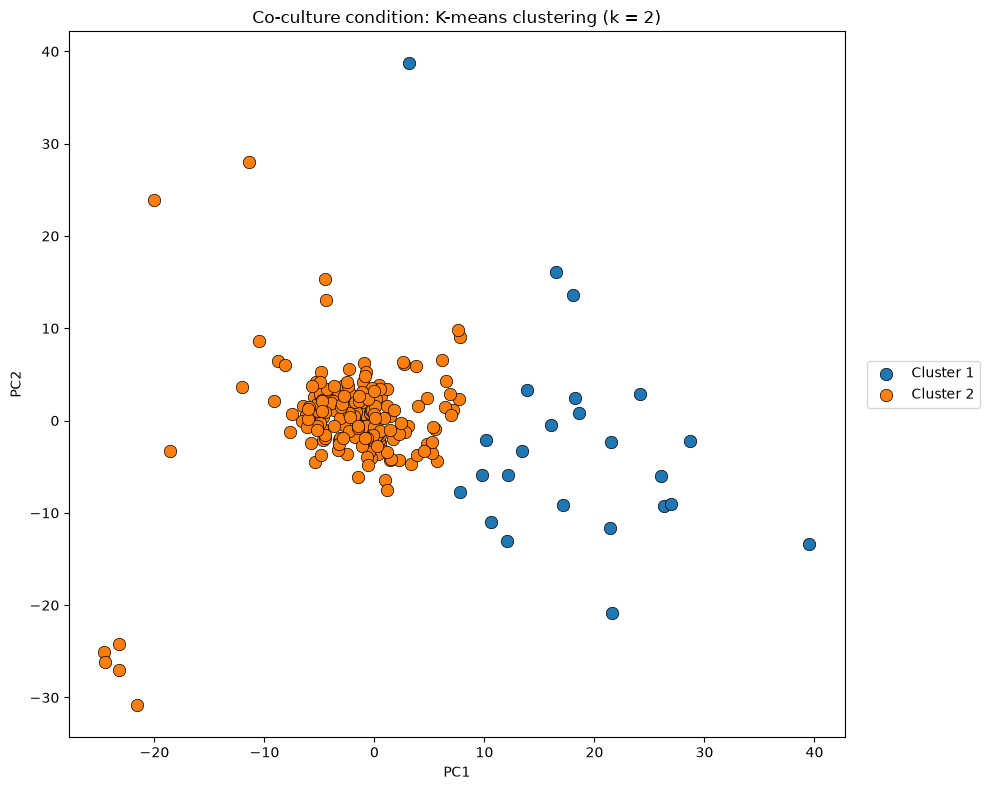

Saved to: results/coculture_kmeans_k2.png


In [47]:
#import packages
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Compute K-means clusters
# Use the first 50 principal components for K-means clustering
n_pcs_for_clustering = 50

# Perform K-means clustering for the Control condition
# using 6 clusters
control_clusters = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
).fit_predict(
    control_pca[:, :n_pcs_for_clustering]
)

# Perform K-means clustering for the IFNγ condition
# using 2 clusters
ifng_clusters = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
).fit_predict(
    ifng_pca[:, :n_pcs_for_clustering]
)

# Perform K-means clustering for the Co-culture condition
# using 2 clusters
coculture_clusters = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
).fit_predict(
    coculture_pca[:, :n_pcs_for_clustering]
)
# Plotting function without perturbation labels
# Define a function to visualize the K-means clusters
# using PC1 and PC2 and save the figure
def plot_kmeans_pca(
    pca,
    clusters,
    title,
    filename
):
    
    # Check that every PCA profile has a corresponding cluster label
    if pca.shape[0] != len(clusters):
        raise ValueError(
            "The number of PCA rows and cluster labels must match."
        )

    # Check that at least two PCs are available for the 2D plot
    if pca.shape[1] < 2:
        raise ValueError(
            "At least two principal components are required for plotting."
        )

    # Create the figure and plotting area
    fig, ax = plt.subplots(figsize=(10, 8))

    # Get the unique cluster numbers
    unique_clusters = np.sort(
        np.unique(clusters)
    )

    # Use a different color for each cluster
    cmap = plt.get_cmap("tab10")

    # Plot the perturbations belonging to each cluster
    for color_index, cluster in enumerate(unique_clusters):

        # Select perturbations belonging to the current cluster
        mask = clusters == cluster

        # Plot their positions using PC1 and PC2
        ax.scatter(
            pca[mask, 0],
            pca[mask, 1],
            s=80,
            color=cmap(color_index),
            edgecolor="black",
            linewidth=0.5,
            label=f"Cluster {cluster + 1}"
        )

    # Add axis labels and figure title
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)

    # Place the cluster legend outside the main plot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    # Adjust the layout
    fig.tight_layout()

    # Create the full path where the figure will be saved
    output_path = os.path.join(
        "results",
        filename
    )

    # Save the figure as a high-resolution PNG file
    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure
    plt.show()

    # Close the figure to free memory
    plt.close(fig)

    # Print the location of the saved figure
    print(f"Saved to: {output_path}")

# Plot and save all three conditions
# Plot and save the Control clustering results
plot_kmeans_pca(
    pca=control_pca,
    clusters=control_clusters,
    title="Control condition: K-means clustering (k = 4)",
    filename="control_kmeans_k4.png"
)

# Plot and save the IFNγ clustering results
plot_kmeans_pca(
    pca=ifng_pca,
    clusters=ifng_clusters,
    title="IFNγ condition: K-means clustering (k = 2)",
    filename="ifng_kmeans_k2.png"
)

# Plot and save the Co-culture clustering results
plot_kmeans_pca(
    pca=coculture_pca,
    clusters=coculture_clusters,
    title="Co-culture condition: K-means clustering (k = 2)",
    filename="coculture_kmeans_k2.png"
)

In [48]:
#import packages
import os
import pandas as pd
# Create separate cluster tables for each condition
# Create a table containing each Control perturbation
# and its assigned K-means cluster
control_cluster_table = pd.DataFrame({
    "perturbation": profiles_control.index.astype(str),
    "cluster": control_clusters
}).sort_values(
    by=["cluster", "perturbation"]
).reset_index(drop=True)

# Create a table containing each IFNγ perturbation
# and its assigned K-means cluster
ifng_cluster_table = pd.DataFrame({
    "perturbation": profiles_ifng.index.astype(str),
    "cluster": ifng_clusters
}).sort_values(
    by=["cluster", "perturbation"]
).reset_index(drop=True)

# Create a table containing each Co-culture perturbation
# and its assigned K-means cluster
coculture_cluster_table = pd.DataFrame({
    "perturbation": profiles_coculture.index.astype(str),
    "cluster": coculture_clusters
}).sort_values(
    by=["cluster", "perturbation"]
).reset_index(drop=True)

In [49]:
# Save the Control cluster assignments as a CSV file
# without including the DataFrame index
control_cluster_table.to_csv(
    "results/control_cluster_assignments.csv",
    index=False
)

# Save the IFNγ cluster assignments as a CSV file
ifng_cluster_table.to_csv(
    "results/ifng_cluster_assignments.csv",
    index=False
)

# Save the Co-culture cluster assignments as a CSV file
coculture_cluster_table.to_csv(
    "results/coculture_cluster_assignments.csv",
    index=False
)

In [50]:
#import packages
import matplotlib.pyplot as plt

# Define a function to save a DataFrame as a formatted table image
def save_table(df, title, filename):

    # Create a figure and adjust its height based on the number of rows
    fig, ax = plt.subplots(
        figsize=(6, len(df) * 0.3 + 1)
    )

    # Hide the axes because only the table will be displayed
    ax.axis("off")

    # Create a table using the DataFrame values and column names
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center"
    )

    # Set the font size manually
    table.auto_set_font_size(False)
    table.set_fontsize(9)

    # Adjust the size and spacing of the table cells
    table.scale(1.2, 1.3)

    # Add a title to the table
    plt.title(title)

    # Save the table as a high-resolution image
    plt.savefig(
        f"results/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    # Close the figure to free memory
    plt.close()

In [51]:
# Save the tables as .png for three conditions
save_table(
    control_cluster_table,
    "Control cluster assignments",
    "control_cluster_assignments.png"
)

save_table(
    ifng_cluster_table,
    "IFNγ cluster assignments",
    "ifng_cluster_assignments.png"
)

save_table(
    coculture_cluster_table,
    "Co-culture cluster assignments",
    "coculture_cluster_assignments.png"
)